In [2]:
# Loss Evaluation
import pandas as pd
import numpy as np
import math
import os

In [7]:
print("Current Directory:",os.getcwd())
if os.getcwd().endswith("run*"):
    path = os.getcwd()
else:
    path = "/home/sim/DeepMind/runs"
    os.chdir(path)
run_num = input("which run?")
run_path = f"/{path}/run_{run_num}"
os.chdir(run_path)
print(f"Directory set to {run_path}")

Current Directory: /home/sim/DeepMind/runs
Directory set to //home/sim/DeepMind/runs/run_0


In [14]:
if "metrics.csv" in os.listdir():
    met = pd.read_csv('metrics.csv')
    print("Run Metrics Found")
else:
    print("Run metrics not found")

Run Metrics Found


In [15]:
print(met.info())
met.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   iteration    500 non-null    int64  
 1   elapsed_s    500 non-null    float64
 2   iter_s       500 non-null    float64
 3   loss         500 non-null    float64
 4   policy_loss  500 non-null    float64
 5   value_loss   500 non-null    float64
 6   games        500 non-null    int64  
 7   positions    500 non-null    int64  
 8   buffer       500 non-null    int64  
 9   selfplay_s   500 non-null    float64
 10  train_s      500 non-null    float64
 11  games_per_s  500 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 47.0 KB
None


,iteration,elapsed_s,iter_s,loss,policy_loss,value_loss,games,positions,buffer,selfplay_s,train_s,games_per_s
0,1,127.8,127.8,7.0674,6.5678,0.4996,96,12540,12540,126.7,1.0,0.758
1,2,256.7,128.9,4.6696,4.3952,0.2744,96,13758,26298,127.4,1.4,0.753
2,3,367.0,110.3,3.7533,3.6171,0.1363,96,10311,36609,108.2,2.0,0.887


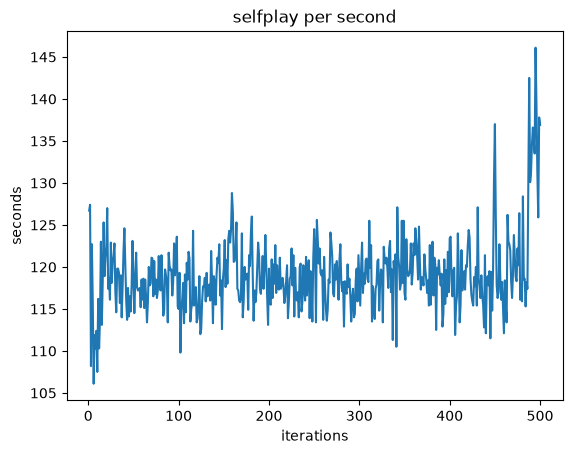

In [33]:
plt.plot(met.iteration,  met.selfplay_s)
plt.xlabel("iterations")
plt.ylabel("seconds")
plt.title("selfplay per second")
plt.show()

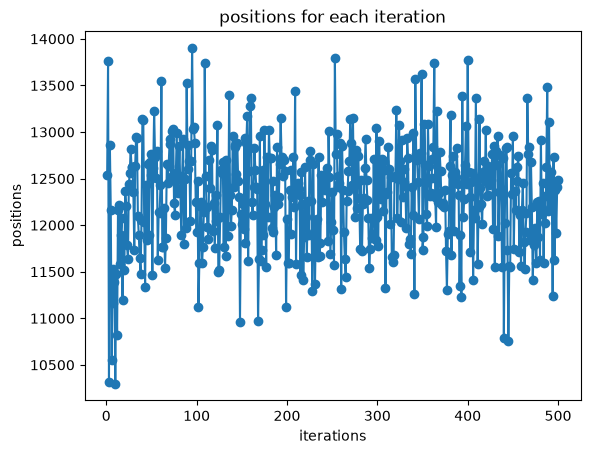

In [40]:
plt.scatter(met.iteration,  met.positions)
plt.plot(met.iteration, met.positions)
plt.xlabel("iterations")
plt.ylabel("positions")
plt.title("positions for each iteration")
plt.show()

In [41]:
met.head(1)

,iteration,elapsed_s,iter_s,loss,policy_loss,value_loss,games,positions,buffer,selfplay_s,train_s,games_per_s
0,1,127.8,127.8,7.0674,6.5678,0.4996,96,12540,12540,126.7,1.0,0.758


In [46]:
m10 = met.copy()[10:]

In [53]:
m10['log_loss'] = np.abs(np.log(m10.loss))
m10['log_policy'] = np.abs(np.log(m10.policy_loss))
m10['log_value'] = np.abs(np.log(m10.value_loss))

In [54]:
m10

,iteration,elapsed_s,iter_s,loss,policy_loss,value_loss,games,positions,buffer,selfplay_s,train_s,games_per_s,log_loss,log_policy,log_value
10,11,1302.8,120.7,2.8662,2.7939,0.0723,96,11479,80000,116.2,4.5,0.826,1.052987,1.027438,2.626931
11,12,1417.6,114.8,2.8888,2.8034,0.0854,96,10822,80000,110.3,4.4,0.870,1.060841,1.030833,2.460409
12,13,1535.8,118.2,2.8914,2.7988,0.0925,96,12163,80000,113.8,4.4,0.844,1.061741,1.029191,2.380547
13,14,1663.3,127.5,2.8693,2.7843,0.0850,96,12220,80000,123.0,4.4,0.780,1.054068,1.023996,2.465104
14,15,1780.9,117.6,2.8446,2.7594,0.0852,96,11579,80000,113.1,4.4,0.849,1.045422,1.015013,2.462754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,61217.9,144.5,2.4825,2.3883,0.0942,96,11626,80000,139.4,5.1,0.689,0.909266,0.870582,2.362335
496,497,61354.0,136.1,2.4789,2.3874,0.0915,96,12382,80000,131.2,4.9,0.732,0.907815,0.870205,2.391416
497,498,61484.9,130.9,2.4971,2.3985,0.0986,96,11914,80000,125.9,4.9,0.763,0.915130,0.874844,2.316684
498,499,61627.8,142.9,2.5295,2.4239,0.1056,96,12409,80000,137.8,5.0,0.696,0.928022,0.885378,2.248097


In [ ]:

from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


def plot_loss(iteration,loss,policy,value, labels={'total_lab':'total','policy_lab':'policy','value_lab':'value'}, title=f"Loss for Run {run_num}", extra_commands=[]):
    plt.plot(iteration, loss, label=labels.get('total_lab'))
    plt.plot(iteration, policy, label=labels.get('policy_lab'))
    plt.plot(iteration, value,  label=labels.get('value_lab'))

    ax = plt.gca()                                    # the current axes
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))   # 5 minor gaps per major interval
    ax.yaxis.set_minor_locator(MultipleLocator(0.25)) # minor y tick every 0.25 loss
    ax.grid(which="major", alpha=0.4)
    ax.grid(which="minor", alpha=0.15)                # faint minor gridlines
    ax.tick_params(which="minor", length=3)
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

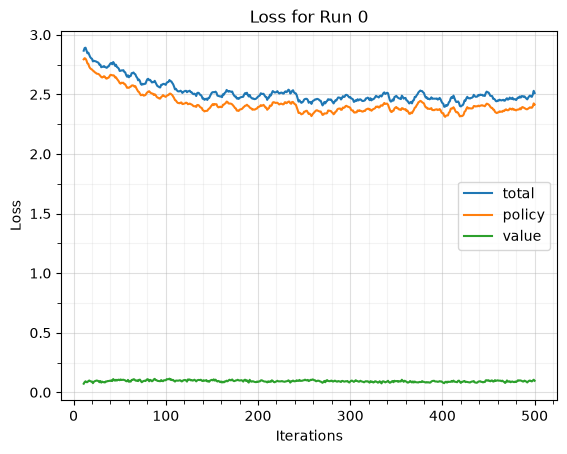

In [62]:
plot_loss(m10.iteration,m10.loss,m10.policy_loss,m10.value_loss)

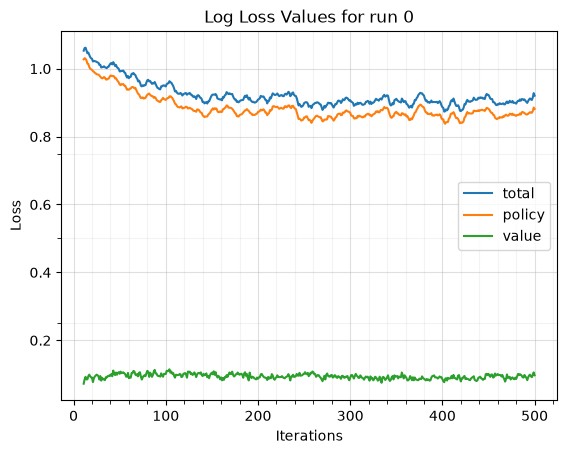

In [ ]:
plot_loss(m10.iteration,m10.log_loss,m10.log_policy,m10.value_loss,title=f"Log Loss Values for run {run_num}")

In [69]:
print(np.mean(m10.log_loss)+np.std(m10.log_loss)*2)
print(np.mean(m10.log_loss)-np.std(m10.log_loss)*2)

0.995821136521123
0.849685363242822


In [70]:
def plot_loss_better(met, hlines=None, band=None, title="loss", ax=None, **plot_kw):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(met.iteration, met.loss,        label="total", **plot_kw)
    ax.plot(met.iteration, met.policy_loss, label="policy")
    ax.plot(met.iteration, met.value_loss,  label="value")

    # optional: a list of y-values -> horizontal reference lines
    if hlines:
        for y in hlines:
            ax.axhline(y, ls="--", lw=1, color="gray")

    # optional: a (mean, sd) tuple -> shaded ±2σ band + mean line
    if band:
        mu, sd = band
        ax.axhspan(mu - 2*sd, mu + 2*sd, color="green", alpha=0.12)
        ax.axhline(mu, ls="--", lw=1, color="k")

    ax.set_xlabel("iteration"); ax.set_ylabel("loss"); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    return ax                      # <- hand the axes back so you can keep customizing
6

6

NameError: name 'mu' is not defined

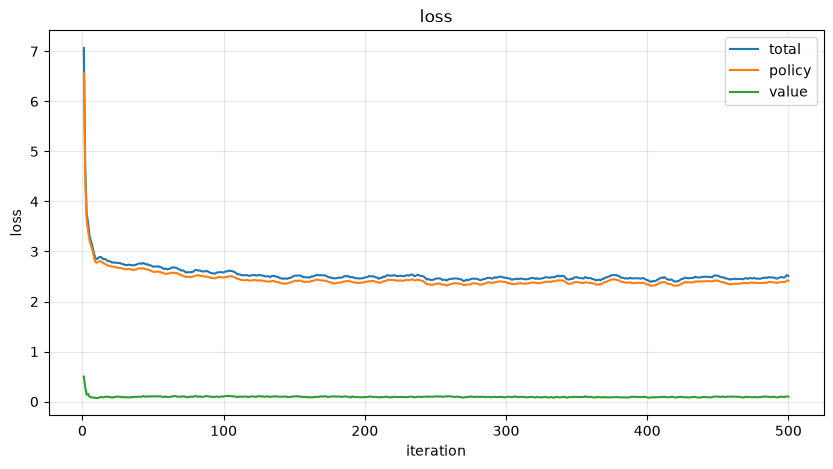

In [72]:
plot_loss_better(met)                                        # plain
plot_loss_better(met, hlines=[mu + 2*sd, mu - 2*sd])         # exactly your case: two static lines
plot_loss_better(met, band=(mu, sd))                         # shaded band + mean instead
plot_loss_better(met, hlines=[mu], band=(mu, sd), title="run_0")   # mix and match


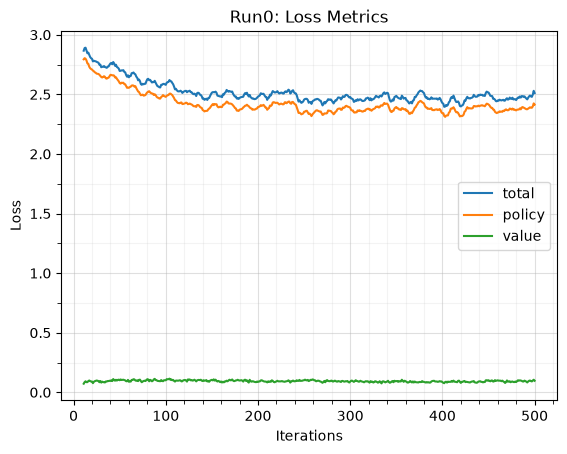

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator



plt.plot(m10.iteration, m10.loss,        label="total")
plt.plot(m10.iteration, m10.policy_loss, label="policy")
plt.plot(m10.iteration, m10.value_loss,  label="value")

ax = plt.gca()                                    # the current axes
ax.xaxis.set_minor_locator(AutoMinorLocator(5))   # 5 minor gaps per major interval
ax.yaxis.set_minor_locator(MultipleLocator(0.25)) # minor y tick every 0.25 loss
ax.grid(which="major", alpha=0.4)
ax.grid(which="minor", alpha=0.15)                # faint minor gridlines
ax.tick_params(which="minor", length=3)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Run0: Loss Metrics")
plt.legend()
plt.show()

In [93]:
def settled_band(loss, smooth_window=11, k=2, max_steps=25):
    """Self-consistently find where the loss settles. Returns (start_idx, mu, sd)."""
    # Loss in array
    L  = np.asarray(loss)

    # Smooth loss over window, periods = 1 for now
    # get the mean values
    sm = pd.Series(L).rolling(smooth_window, center=True, min_periods=1).mean().values

    cut = 0
    for _ in range(max_steps):
        region = L[cut:]
        mu, sd = region.mean(), region.std(ddof=0)
        under  = sm <= mu + k*sd
        new_cut = next((i for i in range(len(under)) if under[i:].all()), len(under)-1)
        if new_cut == cut:
            break
        cut = new_cut
    return cut, mu, sd
for i in range(2,40):
    cut, mu, sd = settled_band(m10.loss.values, smooth_window=i)
    print(f"Window = {i}. Settled from iter {m10.iteration.iloc[cut]}: mu={mu:.4f}, sd={sd:.4f}")


Window = 2. Settled from iter 113: mu=2.4761, sd=0.0302
Window = 3. Settled from iter 112: mu=2.4762, sd=0.0303
Window = 4. Settled from iter 113: mu=2.4761, sd=0.0302
Window = 5. Settled from iter 112: mu=2.4762, sd=0.0303
Window = 6. Settled from iter 113: mu=2.4761, sd=0.0302
Window = 7. Settled from iter 113: mu=2.4761, sd=0.0302
Window = 8. Settled from iter 114: mu=2.4759, sd=0.0302
Window = 9. Settled from iter 113: mu=2.4761, sd=0.0302
Window = 10. Settled from iter 114: mu=2.4759, sd=0.0302
Window = 11. Settled from iter 114: mu=2.4759, sd=0.0302
Window = 12. Settled from iter 114: mu=2.4759, sd=0.0302
Window = 13. Settled from iter 114: mu=2.4759, sd=0.0302
Window = 14. Settled from iter 115: mu=2.4758, sd=0.0301
Window = 15. Settled from iter 115: mu=2.4758, sd=0.0301
Window = 16. Settled from iter 116: mu=2.4757, sd=0.0300
Window = 17. Settled from iter 116: mu=2.4757, sd=0.0300
Window = 18. Settled from iter 117: mu=2.4755, sd=0.0299
Window = 19. Settled from iter 117: mu=